In [26]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.checkpoint.memory import InMemorySaver

from langgraph.types import interrupt, Command

from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field

from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langchain_core.prompts import PromptTemplate
from langchain.messages import RemoveMessage

from langgraph.graph import MessagesState

from dotenv import load_dotenv
from huggingface_hub import InferenceClient
import requests, operator, random, sqlite3

from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [27]:
load_dotenv()

True

In [28]:
llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    task="text-generation",
    max_new_tokens=256,
    temperature=0.7
)
model = ChatHuggingFace(llm=llm)
MAX_TOKENS = 150

In [29]:
class ChatState(MessagesState):
    summary: str

In [30]:
def chat(state: ChatState):
    messages = []
    summary = state.get("summary", "")
    if summary:
        messages.append({
            "role": "system",
            "content": f"Conversation summary: \n{summary}"
        })

    messages.extend(state["messages"])
    response = model.invoke(messages)
    return {"messages": [response], "summary": summary}

In [31]:
def summarize(state: ChatState):
    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [32]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

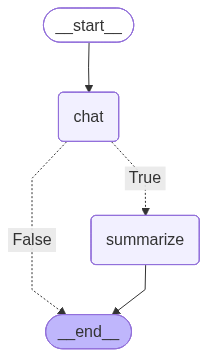

In [33]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("summarize", summarize)
builder.add_edge(START, "chat")
builder.add_conditional_edges(
    "chat",
    should_summarize,{
        True: "summarize",
        False: END
    }
)

graph = builder.compile(checkpointer=InMemorySaver())
graph

In [34]:
config = {"configurable": {"thread_id": "t1"}}

In [35]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [36]:
def generate(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [37]:
generate('Quantum Physics')
show_state()


--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics, also known as quantum mechanics, is a fundamental branch of phy


In [38]:
generate('How is Albert Einstien related?')
show_state()


--- STATE ---
summary: 
num_messages: 4
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics, also known as quantum mechanics, is a fundamental branch of phy
- HumanMessage : How is Albert Einstien related?
- AIMessage : Albert Einstein's contributions to quantum physics are significant, but his rela


In [39]:
generate('What are some of Einstien"s fampus work')
show_state()


--- STATE ---
summary: 
num_messages: 6
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics, also known as quantum mechanics, is a fundamental branch of phy
- HumanMessage : How is Albert Einstien related?
- AIMessage : Albert Einstein's contributions to quantum physics are significant, but his rela
- HumanMessage : What are some of Einstien"s fampus work
- AIMessage : Albert Einstein is one of the most renowned physicists in history, known for his


In [40]:
generate('Explain special theory of relativity')
show_state()


--- STATE ---
summary: Certainly! Here's a summary of the conversation:

The discussion was about Albert Einstein and his contributions to quantum physics, particularly his foundational work and his critical stance towards some aspects of quantum mechanics. Key points included:

1. **Foundational Contributions**:
   - Einstein's work on the photoelectric effect, which introduced the concept of light quanta (photons) and earned him the Nobel Prize in Physics in 1921.

2. **Criticism of Quantum Mechanics**:
   - Einstein was critical of the probabilistic nature of quantum mechanics, famously stating, "God does not play dice." He introduced the EPR paradox (Einstein-Podolsky-Rosen paradox) to challenge the completeness of quantum mechanics.

3. **EPR Paradox**:
   - Einstein, Podolsky, and Rosen introduced the EPR paradox in 1935, which suggested that quantum mechanics was incomplete and did not provide a complete description of reality.

The conversation then shifted to Einstein's most 